In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../CSVs/time_series_15min_singleindex.csv")

In [4]:
print("========== BASIC DATA OVERVIEW ==========")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Shape ---")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Numerical Columns ---")
print(df.select_dtypes(include="number").columns.tolist())

print("\n--- Categorical Columns ---")
print(df.select_dtypes(exclude="number").columns.tolist())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Unique Values ---")
print(df.nunique())

print("\n--- Numerical Summary ---")
print(df.describe())

print("\n--- Date Information ---")
date_columns = df.select_dtypes(include=["datetime"]).columns.tolist()

if date_columns:
    for col in date_columns:
        print(f"{col}:")
        print("Minimum:", df[col].min())
        print("Maximum:", df[col].max())
else:
    print("No datetime columns detected.")

print("\n========== EDA OVERVIEW COMPLETE ==========")

========== BASIC DATA OVERVIEW ==========

--- First 5 Rows ---
          utc_timestamp        cet_cest_timestamp  \
0  2014-12-31T23:00:00Z  2015-01-01T00:00:00+0100   
1  2014-12-31T23:15:00Z  2015-01-01T00:15:00+0100   
2  2014-12-31T23:30:00Z  2015-01-01T00:30:00+0100   
3  2014-12-31T23:45:00Z  2015-01-01T00:45:00+0100   
4  2015-01-01T00:00:00Z  2015-01-01T01:00:00+0100   

   AT_load_actual_entsoe_transparency  AT_load_forecast_entsoe_transparency  \
0                                 NaN                                   NaN   
1                                 NaN                                   NaN   
2                                 NaN                                   NaN   
3                                 NaN                                   NaN   
4                                 NaN                                   NaN   

   AT_price_day_ahead  AT_solar_generation_actual  \
0                 NaN                         NaN   
1                 NaN               

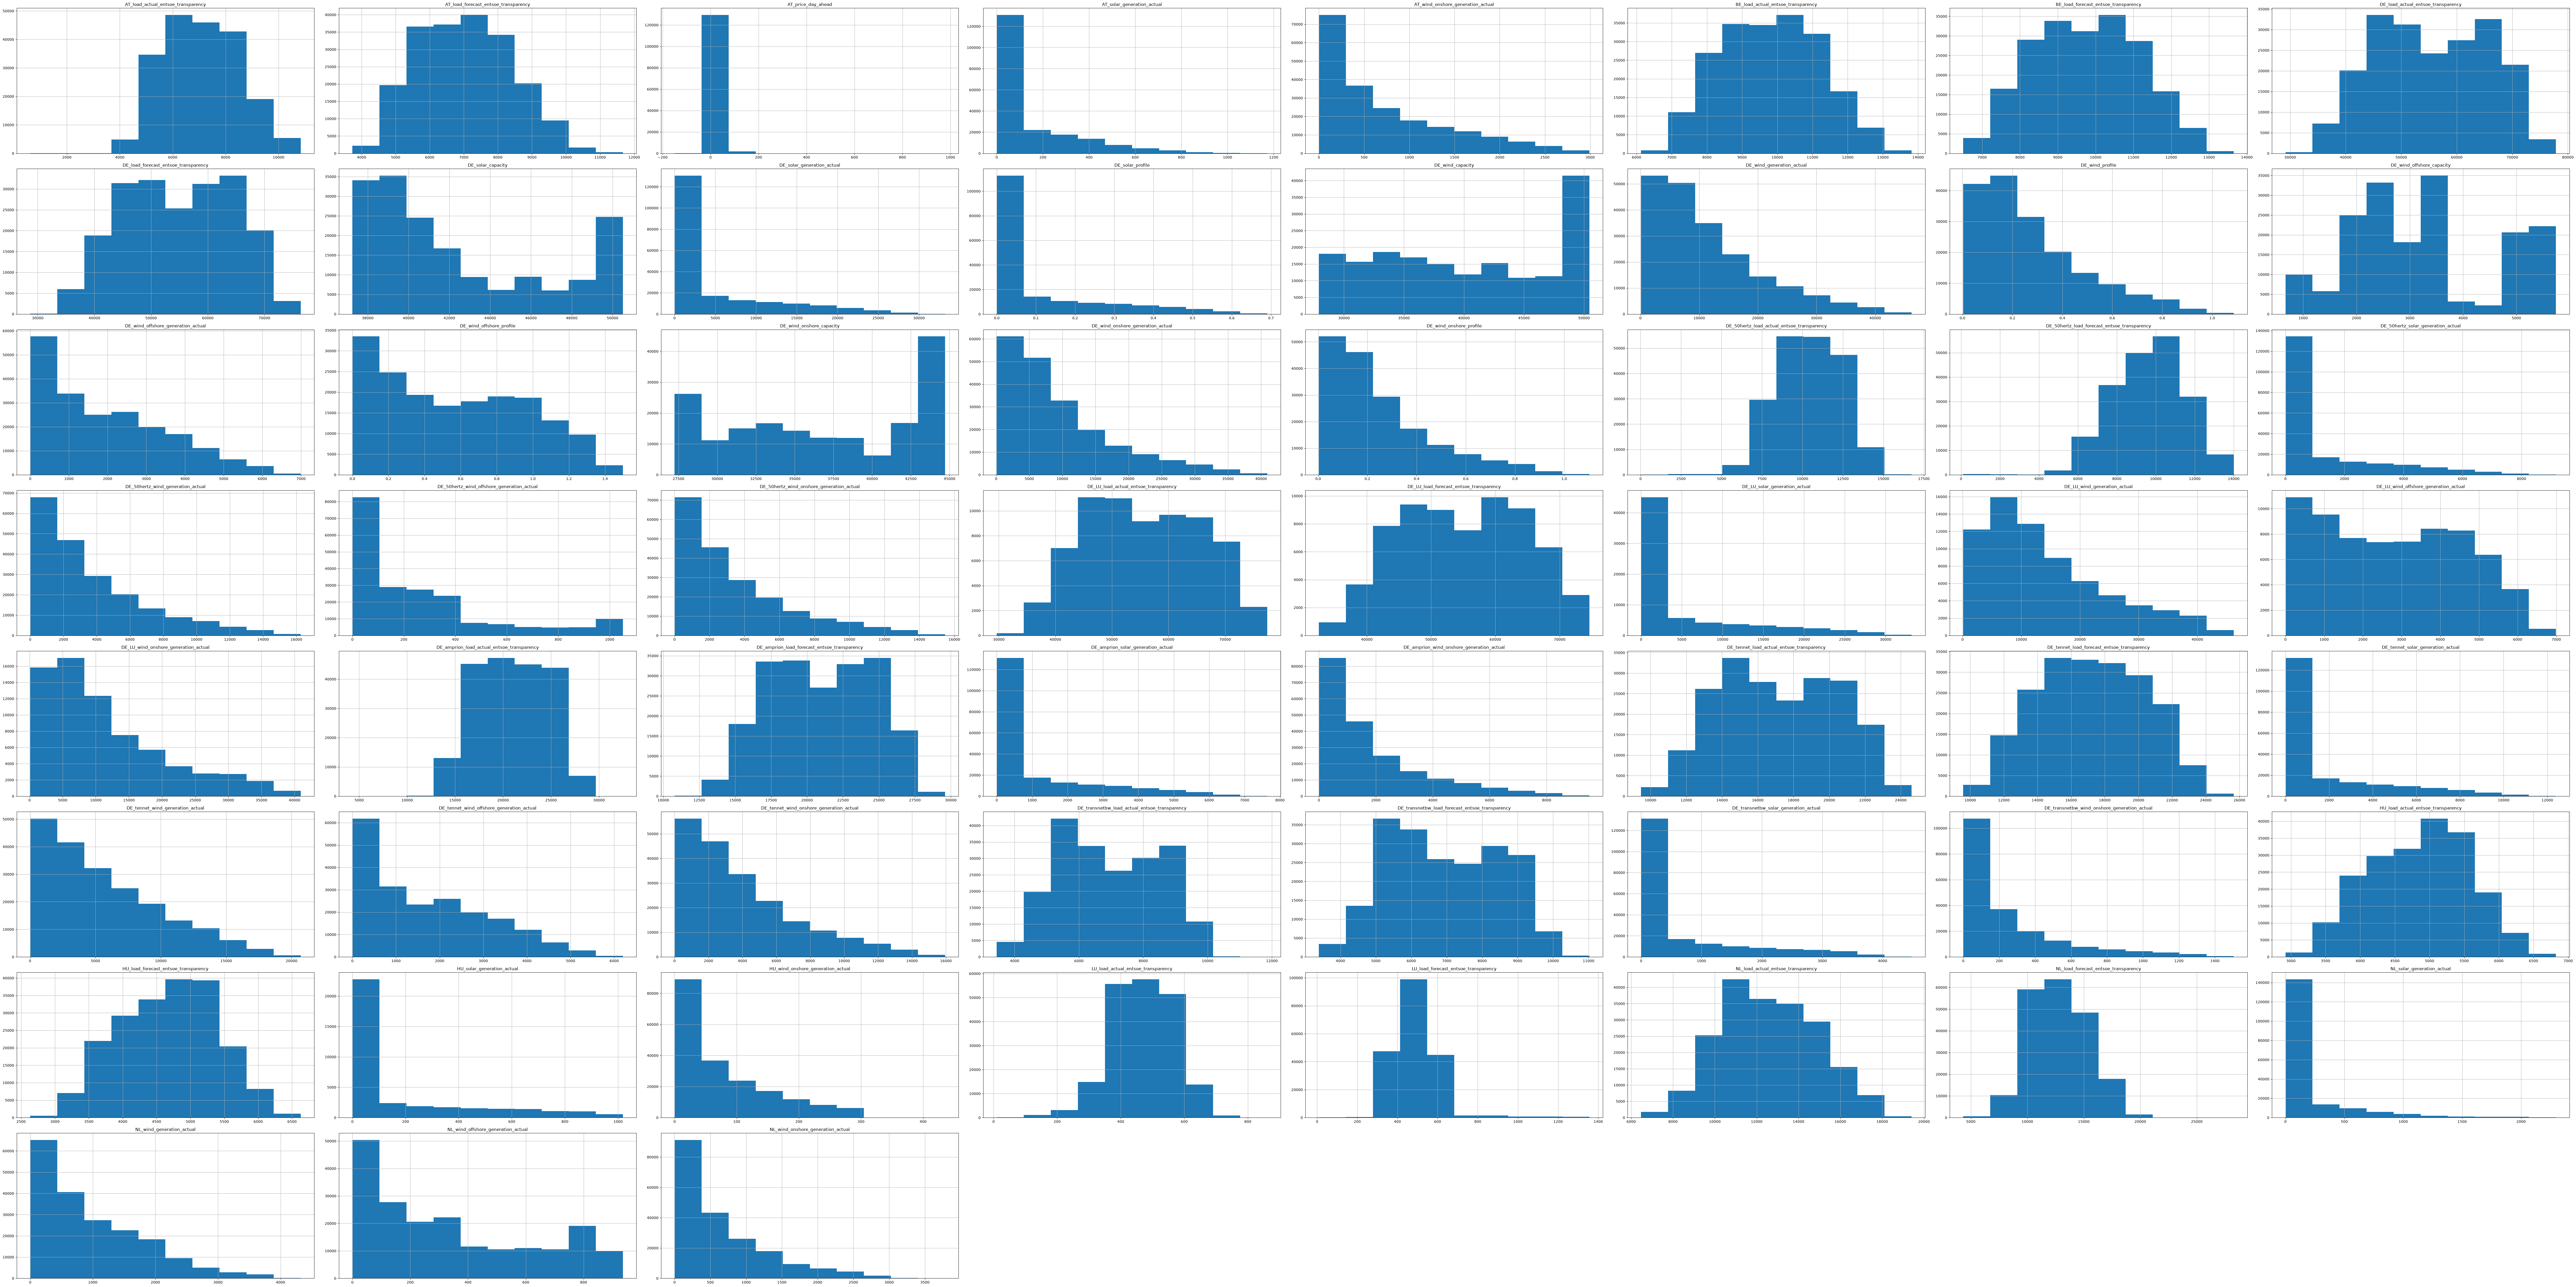

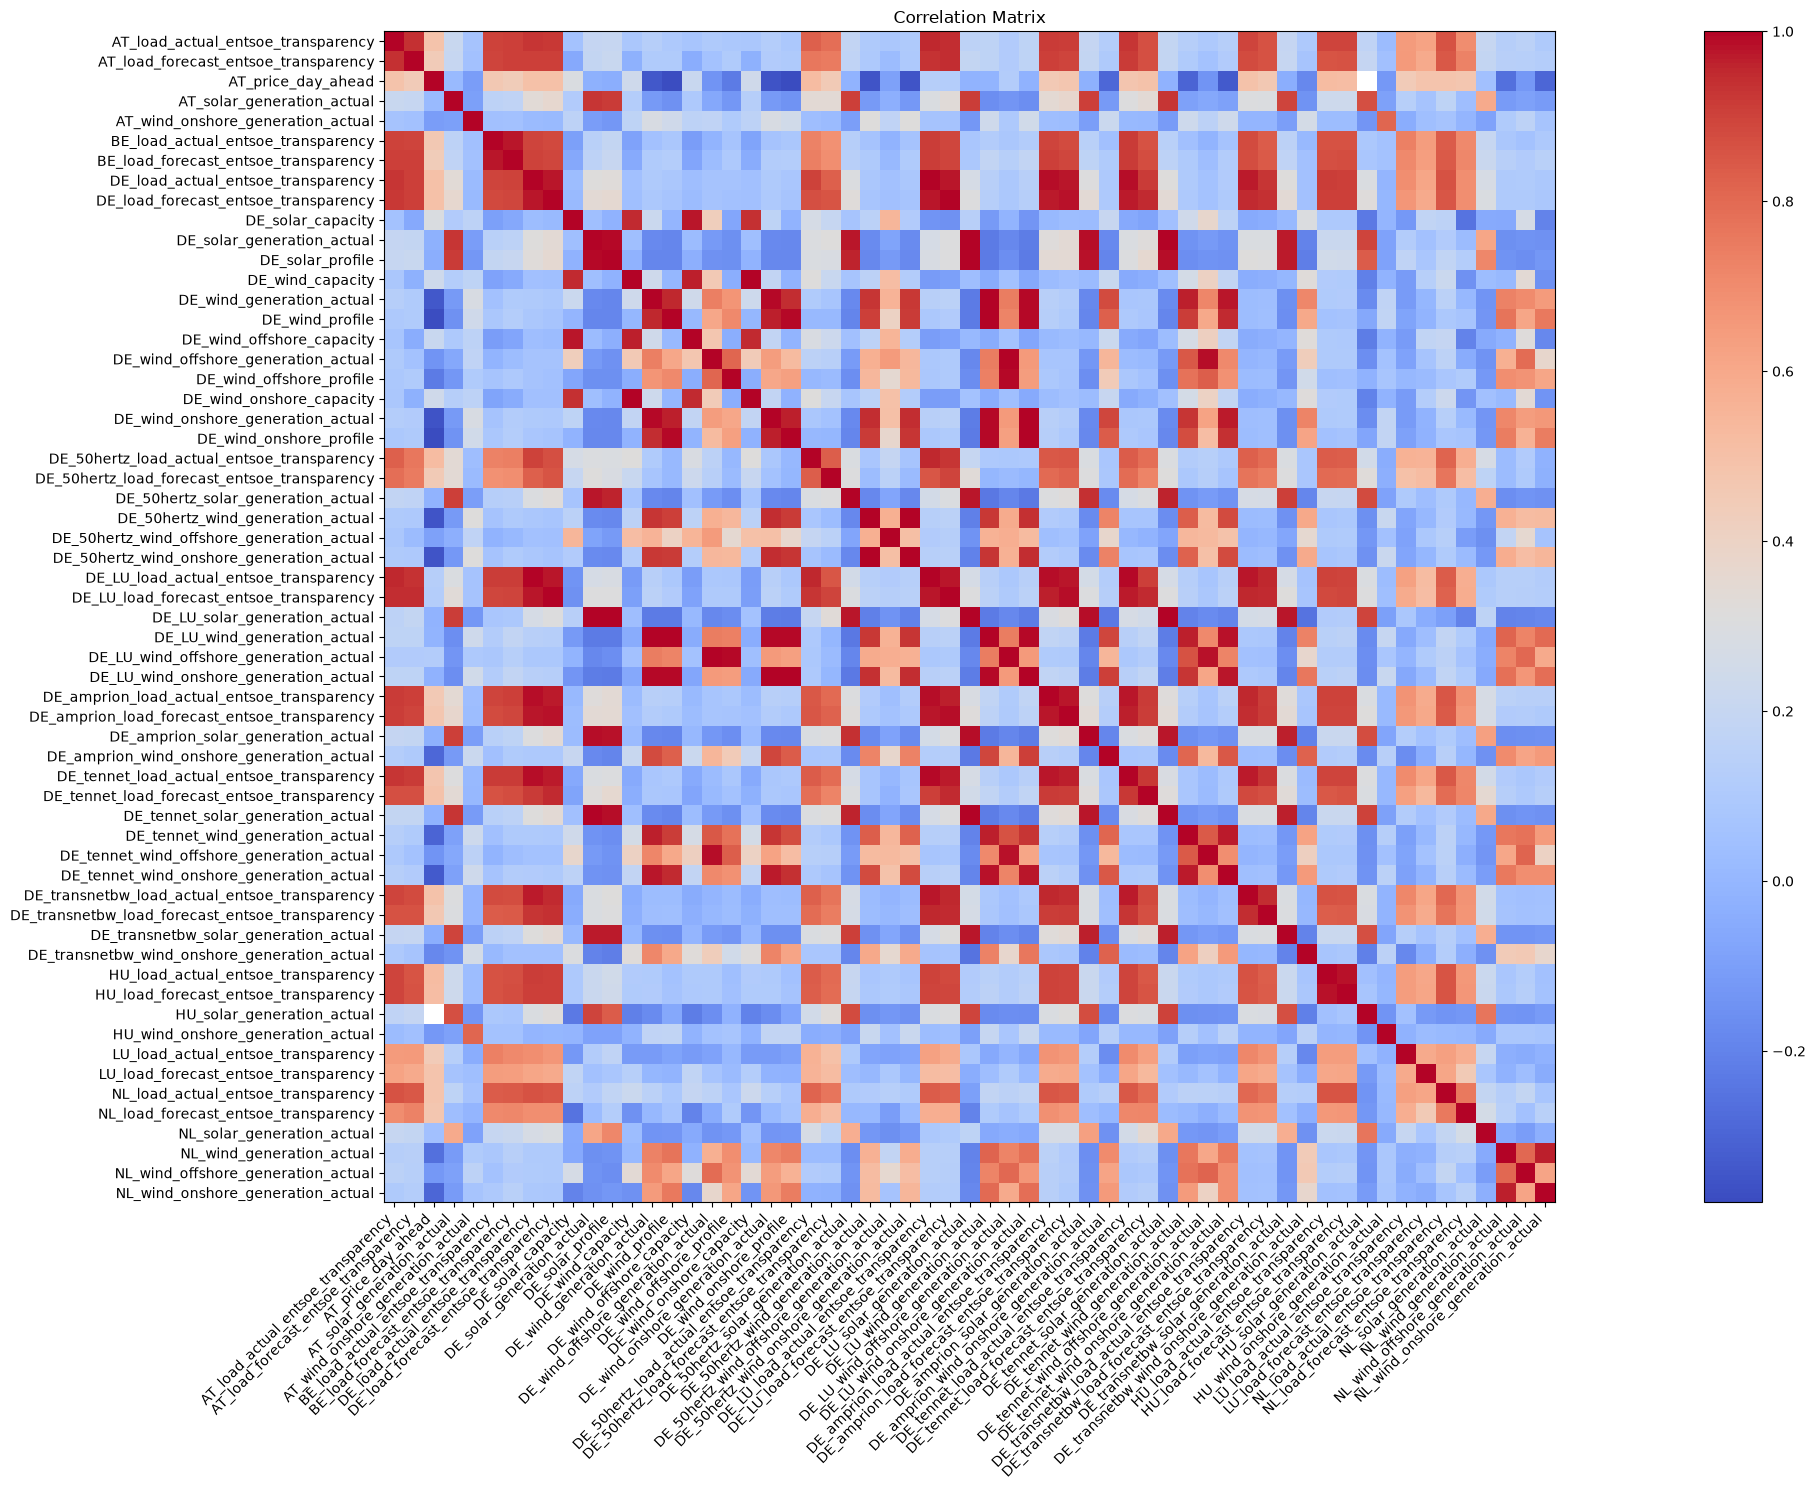

In [10]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

if not numeric_df.empty:
    numeric_df.hist(figsize=(100, 50))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(30, 15))
    plt.imshow(numeric_df.corr(), cmap="coolwarm")
    plt.colorbar()
    plt.title("Correlation Matrix")
    plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for histogram/correlation plots.")

## EDA Findings

- The dataset contains 201,604 rows and 61 columns, representing a high-frequency time series with 15-minute observations.
- The dataset contains timestamp information together with electricity load, electricity price, solar generation, wind generation, capacity, and profile-related variables.
- Missing values are substantial, with 1,295,838 total null entries, and the missingness is concentrated in a subset of variables.
- The dataset contains no duplicate rows, indicating that the time-series records are unique at the row level.
- The data is structurally suitable for temporal analysis, trend analysis, and missing-value diagnostics.
- The high-frequency 15-minute resolution provides detailed information about short-term variations in electricity demand and renewable energy generation.
- Overall, this dataset provides a strong basis for time-series forecasting, feature engineering, renewable-energy analysis, and electricity-market analysis, provided that missing values are handled appropriately.